In [98]:
# Import Necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
# Import dataset
df_hour = pd.read_csv('hour.csv')
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


#### Data Wrangling

In [100]:
# Check the number of rows and columns
df_hour.shape

(17379, 17)

In [101]:
# Get an overview of columns, their data types and possible missing values.
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [102]:
# Confirm that there are truly no missing values
print(df_hour.isna().sum())

# Not necessary, but cross-checking the number of columns with no missing values 
print()
print(df_hour.notna().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

instant       17379
dteday        17379
season        17379
yr            17379
mnth          17379
hr            17379
holiday       17379
weekday       17379
workingday    17379
weathersit    17379
temp          17379
atemp         17379
hum           17379
windspeed     17379
casual        17379
registered    17379
cnt           17379
dtype: int64


In [103]:
# Identify and handle duplicates across the entire dataset
df_hour.duplicated().sum()

np.int64(0)

In [104]:
# Drop unnecessary columns
df_hour = df_hour.drop(['instant', 'dteday'], axis=1)
df_hour.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [105]:
# The shape should two columns less now
df_hour.shape

(17379, 15)

### Data Formatting
Ensuring Appropriate data types for the sake of EDA

In [106]:
# Convert 'season' data type from integer to categorical
season_string = {
    1: 'winter',
    2: 'spring',
    3: 'summer',
    4: 'fall'
}

df_hour['season'] = df_hour['season'].map(season_string)
df_hour['season'].head()

0    winter
1    winter
2    winter
3    winter
4    winter
Name: season, dtype: object

In [107]:
# Convert 'mnth' from int to categorical as well

month_string = {
    1: 'january',
    2: 'february',
    3: 'march',
    4: 'april',
    5: 'may', 
    6: 'june',
    7: 'july',
    8: 'august',
    9: 'september',
    10: 'october',
    11: 'november',
    12: 'december'
}

df_hour['mnth'] = df_hour['mnth'].map(month_string)
df_hour['mnth'].head()

0    january
1    january
2    january
3    january
4    january
Name: mnth, dtype: object

In [108]:
# Change 'weekday' from int to categorical as well

week_string = {
    1: 'monday',
    2: 'tuesday',
    3: 'wednesday',
    4: 'thursday',
    5: 'friday',
    6: 'saturday',
    0: 'sunday'
}

df_hour['weekday'] = df_hour['weekday'].map(week_string)
df_hour['weekday'].head()

0    saturday
1    saturday
2    saturday
3    saturday
4    saturday
Name: weekday, dtype: object

In [109]:
# Review the data again
df_hour.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,winter,0,january,0,0,saturday,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,winter,0,january,1,0,saturday,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,winter,0,january,2,0,saturday,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,winter,0,january,3,0,saturday,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,winter,0,january,4,0,saturday,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Denormalising Environmental Variables
The UCI repository provides normalized values for temperature, humidity, and windspeed. To make the data interpretable for EDA, we reverse the Min-Max scaling using the following formula:$$Value = n \times (Max - Min) + Min$$Where $n$ is the normalized value. Based on the UCI documentation, the specific transformations are:

Temperature (temp):$$n \times (39 - (-8)) + (-8) \implies \mathbf{n \times 47 - 8}$$Feeling/Apparent Temperature (atemp):$$n \times (50 - (-16)) + (-16) \implies \mathbf{n \times 66 - 16}$$Humidity (hum):$$\mathbf{n \times 100}$$Windspeed (windspeed):$$\mathbf{n \times 67}$$

In [134]:
# Reversing Min-Max scaling to get actual units: Actual = Value in the equation above
# Actual = Normalized * (Max - Min) + Min

df_hour['temp2'] = (df_hour['temp'] * 47) - 8
df_hour['atemp2'] = (df_hour['atemp'] * 66) - 16
df_hour['hum2'] = df_hour['hum'] * 100
df_hour['windspeed2'] = df_hour['windspeed'] * 67

In [135]:
df_hour.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,cnt,temp2,atemp2,hum2,windspeed2,temp2_binned,hum2_binned,windspeed2_binned,hour_binned,cnt_binned
0,winter,0,january,0,0,saturday,0,1,0.24,0.2879,...,16,3.28,3.0014,81.0,0.0,Cold,High,Calm,Early Morning,Low
1,winter,0,january,1,0,saturday,0,1,0.22,0.2727,...,40,2.34,1.9982,80.0,0.0,Cold,High,Calm,Early Morning,Low
2,winter,0,january,2,0,saturday,0,1,0.22,0.2727,...,32,2.34,1.9982,80.0,0.0,Cold,High,Calm,Early Morning,Low
3,winter,0,january,3,0,saturday,0,1,0.24,0.2879,...,13,3.28,3.0014,75.0,0.0,Cold,High,Calm,Early Morning,Low
4,winter,0,january,4,0,saturday,0,1,0.24,0.2879,...,1,3.28,3.0014,75.0,0.0,Cold,High,Calm,Early Morning,Low


### Data Binning for Categorization

In [136]:
# Define bin edges and labels for temperature

temp2_bins = np.linspace(df_hour['temp2'].min(), df_hour['temp2'].max(), 4)
temp2_labels = ['Cold', 'Mild', 'Hot']
df_hour['temp2_binned'] = pd.cut(df_hour['temp2'], bins=temp2_bins, labels=temp2_labels, include_lowest=True)

# Define bin edges and labels for humidity
hum2_bins = np.linspace(df_hour['hum2'].min(), df_hour['hum2'].max(), 4)
hum2_labels = ['Low', 'Medium', 'High']
df_hour['hum2_binned'] = pd.cut(df_hour['hum2'], bins=hum2_bins, labels=hum2_labels, include_lowest=True)

# Define bin edges and labels for windspeed
windspeed2_bins = np.linspace(df_hour['windspeed2'].min(), df_hour['windspeed2'].max(), 4)
windspeed2_labels = ['Calm', 'Breezy', 'Windy']
df_hour['windspeed2_binned'] = pd.cut(df_hour['windspeed2'], bins=windspeed2_bins, labels=windspeed2_labels, include_lowest=True)

# Define bin edges and labels for hour
hour_bins = [0, 6, 12, 18, 24]
hour_labels = ['Early Morning', 'Morning', 'Afternoon', 'Evening']
df_hour['hour_binned'] = pd.cut(df_hour['hr'], bins=hour_bins, labels=hour_labels, right=False) # right=False ensures the bins are left-inclusive.

# Define bin edges and labels for count of rentals
cnt_bins = np.linspace(df_hour['cnt'].min(), df_hour['cnt'].max(), 4)
cnt_labels = ['Low', 'Medium', 'High']
df_hour['cnt_binned'] = pd.cut(df_hour['cnt'], bins=cnt_bins, labels=cnt_labels, include_lowest=True)

In [137]:
df_hour.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,cnt,temp2,atemp2,hum2,windspeed2,temp2_binned,hum2_binned,windspeed2_binned,hour_binned,cnt_binned
0,winter,0,january,0,0,saturday,0,1,0.24,0.2879,...,16,3.28,3.0014,81.0,0.0,Cold,High,Calm,Early Morning,Low
1,winter,0,january,1,0,saturday,0,1,0.22,0.2727,...,40,2.34,1.9982,80.0,0.0,Cold,High,Calm,Early Morning,Low
2,winter,0,january,2,0,saturday,0,1,0.22,0.2727,...,32,2.34,1.9982,80.0,0.0,Cold,High,Calm,Early Morning,Low
3,winter,0,january,3,0,saturday,0,1,0.24,0.2879,...,13,3.28,3.0014,75.0,0.0,Cold,High,Calm,Early Morning,Low
4,winter,0,january,4,0,saturday,0,1,0.24,0.2879,...,1,3.28,3.0014,75.0,0.0,Cold,High,Calm,Early Morning,Low


### EDA
#### Descriptive Statistics

In [138]:
# stats for the continuous variables
df_hour[['casual', 'registered', 'cnt']].describe().T

,count,mean,std,min,25%,50%,75%,max
casual,17379.0,35.676218,49.305030,0.0,4.0,17.0,48.0,367.0
registered,17379.0,153.786869,151.357286,0.0,34.0,115.0,220.0,886.0
cnt,17379.0,189.463088,181.387599,1.0,40.0,142.0,281.0,977.0


In [139]:
df_hour.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,cnt,temp2,atemp2,hum2,windspeed2,temp2_binned,hum2_binned,windspeed2_binned,hour_binned,cnt_binned
0,winter,0,january,0,0,saturday,0,1,0.24,0.2879,...,16,3.28,3.0014,81.0,0.0,Cold,High,Calm,Early Morning,Low
1,winter,0,january,1,0,saturday,0,1,0.22,0.2727,...,40,2.34,1.9982,80.0,0.0,Cold,High,Calm,Early Morning,Low
2,winter,0,january,2,0,saturday,0,1,0.22,0.2727,...,32,2.34,1.9982,80.0,0.0,Cold,High,Calm,Early Morning,Low
3,winter,0,january,3,0,saturday,0,1,0.24,0.2879,...,13,3.28,3.0014,75.0,0.0,Cold,High,Calm,Early Morning,Low
4,winter,0,january,4,0,saturday,0,1,0.24,0.2879,...,1,3.28,3.0014,75.0,0.0,Cold,High,Calm,Early Morning,Low


In [140]:
# Value count for categorical variables

cat_columns = ['season', 'yr', 'mnth', 'weekday', 'weathersit', 'temp2_binned', "hum2_binned", 'windspeed2_binned', "hour_binned", "cnt_binned"]
value_counts_dict = {}
for column in cat_columns:
    value_counts_dict[column] = df_hour[column].value_counts()
for column, value_counts in value_counts_dict.items(): # for keys & values in key-value pairs
    print(f"Value counts for {column}:\n{value_counts}\n")

Value counts for season:
season
summer    4496
spring    4409
winter    4242
fall      4232
Name: count, dtype: int64

Value counts for yr:
yr
1    8734
0    8645
Name: count, dtype: int64

Value counts for mnth:
mnth
july         1488
may          1488
december     1483
august       1475
march        1473
october      1451
june         1440
april        1437
september    1437
november     1437
january      1429
february     1341
Name: count, dtype: int64

Value counts for weekday:
weekday
saturday     2512
sunday       2502
friday       2487
monday       2479
wednesday    2475
thursday     2471
tuesday      2453
Name: count, dtype: int64

Value counts for weathersit:
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

Value counts for temp2_binned:
temp2_binned
Mild    8885
Cold    4770
Hot     3724
Name: count, dtype: int64

Value counts for hum2_binned:
hum2_binned
Medium    8645
High      7581
Low       1153
Name: count, dtype: int64

Value counts for 

In [164]:
# Check the mode for the categorical variables
mode_values = df_hour[cat_columns].mode().iloc[0]
print(mode_values)

season                  summer
yr                         1.0
mnth                      july
weekday               saturday
weathersit                 1.0
temp2_binned              Mild
hum2_binned             Medium
windspeed2_binned         Calm
hour_binned          Afternoon
cnt_binned                 Low
Name: 0, dtype: object


#### Group-By Analysis

In [208]:
# Group by season and calculate the sum of 'casual', 'registered' and 'count'
seasonal_data = df_hour.groupby('season')[['casual', 'registered', 'cnt']].sum().reset_index()
seasonal_data

# Count gives the total riders per season
total = seasonal_data['cnt']

# Calculate the percentage of casual and registered riders per season
seasonal_data['casual_percentage'] = (seasonal_data['casual'] / total) * 100
seasonal_data['registered_percentage'] = (seasonal_data['registered'] / total) * 100

# Display the result
print(seasonal_data[['season', 'casual_percentage', 'registered_percentage', 'cnt']])

   season  casual_percentage  registered_percentage      cnt
0    fall          15.420627              84.579373   841613
1  spring          22.155937              77.844063   918589
2  summer          21.306646              78.693354  1061129
3  winter          12.861410              87.138590   471348


In [196]:
# Group by month and calculate the sum of 'casual', 'registered' and 'count'
monthly_data = df_hour.groupby('mnth')[['casual', 'registered', 'cnt']].sum().reset_index()
monthly_data

# Again, Count gives the total riders per month
monthly_total = monthly_data['cnt']

# Calculate the percentage of casual and registered riders per month
monthly_data['casual_percentage'] = (monthly_data['casual'] / monthly_total) * 100
monthly_data['registered_percentage'] = (monthly_data['registered'] / monthly_total) * 100

# Display the result
print(monthly_data[['mnth', 'casual_percentage', 'registered_percentage']])

         mnth  casual_percentage  registered_percentage
0       april          22.595078              77.404922
1      august          20.512594              79.487406
2    december          10.279289              89.720711
3    february           9.886225              90.113775
4     january           8.924429              91.075571
5        july          22.657618              77.342382
6        june          21.339023              78.660977
7       march          19.414643              80.585357
8         may          22.697672              77.302328
9    november          14.363637              85.636363
10    october          18.538740              81.461260
11  september          20.325095              79.674905


In [ ]:
# Group by weekday and calculate the sum of 'casual', 'registered' and 'count'

week_data = df_hour.groupby('weekday')[['casual', 'registered', 'cnt']].mean().reset_index()
week_data

,weekday,casual,registered,cnt
0,friday,31.458786,164.677121,196.135907
1,monday,28.553449,155.191206,183.744655
2,saturday,61.246815,128.962978,190.209793
3,sunday,56.163469,121.305356,177.468825
4,thursday,24.872521,171.564144,196.436665
5,tuesday,23.580514,167.658377,191.238891
6,wednesday,23.159192,167.971313,191.130505


In [206]:
# Group by hour and calculate the sum of 'casual', 'registered' and 'count'

hourly_data = df_hour.groupby('hour_binned', observed=False)[['casual', 'registered', 'cnt']].mean().reset_index()
print(hourly_data.head())

     hour_binned     casual  registered         cnt
0  Early Morning   4.507717   20.400842   24.908559
1        Morning  28.978899  179.121789  208.100688
2      Afternoon  73.184000  222.299886  295.483886
3        Evening  35.305403  190.452152  225.757555


### Correlations

                  yr        hr   holiday  workingday  weathersit      temp  \
yr          1.000000 -0.003867  0.006692   -0.002196   -0.019157  0.040913   
hr         -0.003867  1.000000  0.000479    0.002285   -0.020203  0.137603   
holiday     0.006692  0.000479  1.000000   -0.252471   -0.017036 -0.027340   
workingday -0.002196  0.002285 -0.252471    1.000000    0.044672  0.055390   
weathersit -0.019157 -0.020203 -0.017036    0.044672    1.000000 -0.102640   
temp        0.040913  0.137603 -0.027340    0.055390   -0.102640  1.000000   
atemp       0.039222  0.133750 -0.030973    0.054667   -0.105563  0.987672   
hum        -0.083546 -0.276498 -0.010588    0.015688    0.418130 -0.069881   
windspeed  -0.008740  0.137252  0.003988   -0.011830    0.026226 -0.023125   
casual      0.142779  0.301202  0.031564   -0.300942   -0.152628  0.459616   
registered  0.253684  0.374141 -0.047345    0.134326   -0.120966  0.335361   
cnt         0.250495  0.394071 -0.030927    0.030284   -0.142426

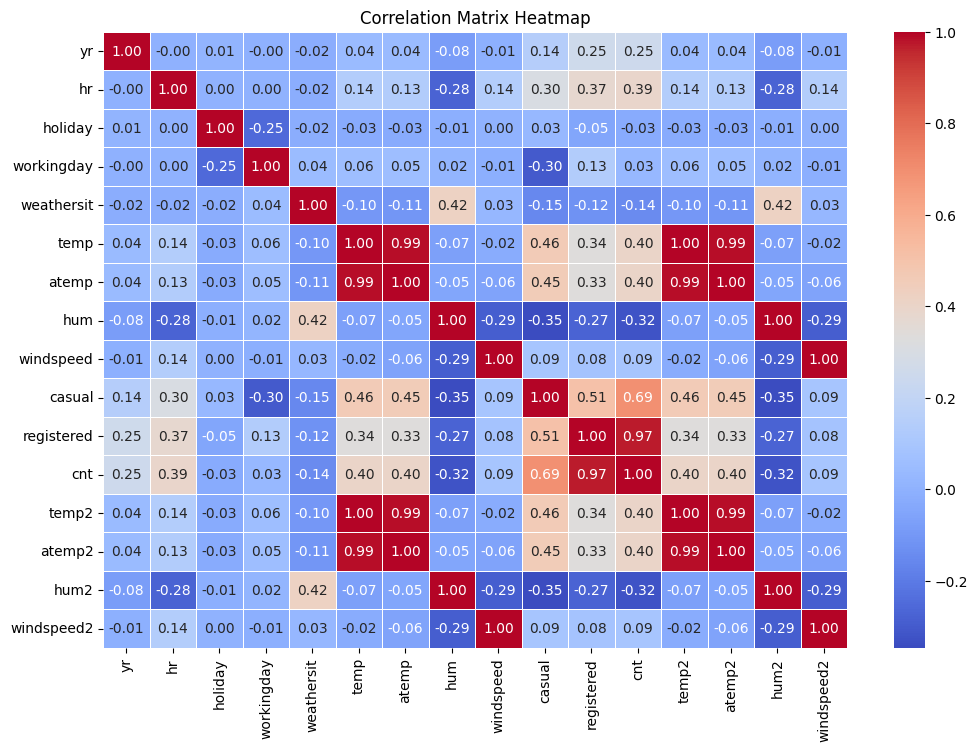

In [215]:
correlation_matrix = df_hour.corr(numeric_only=True)
print(correlation_matrix)

# Generate a heatmap to visualise the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

               temp2    atemp2      hum2  windspeed2
cnt         0.404772  0.400929 -0.322911    0.093234
casual      0.459616  0.454080 -0.347028    0.090287
registered  0.335361  0.332559 -0.273933    0.082321


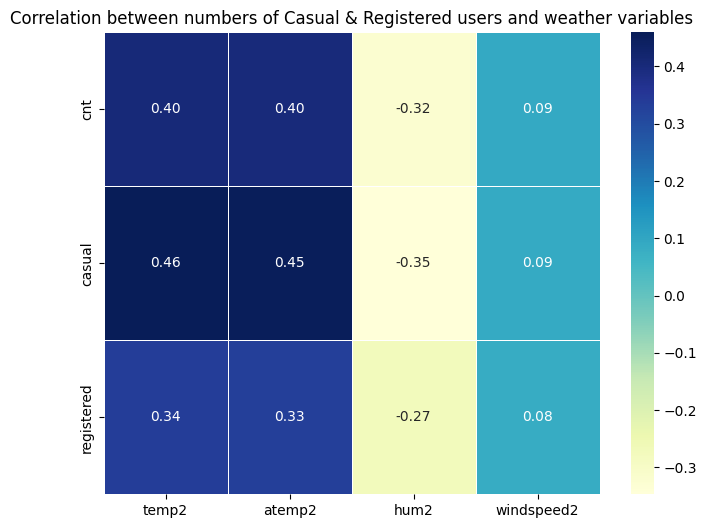

In [219]:
# Extract the correlations of 'casual', 'registered', and 'count' with the other variables
rider_correlations = correlation_matrix.loc[['cnt', 'casual', 'registered'], ['temp2', 'atemp2', 'hum2', 'windspeed2']]
print(rider_correlations)

# Generate a heatmap for this 
plt.figure(figsize=(8, 6))
sns.heatmap(rider_correlations, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Correlation between numbers of Casual & Registered users and weather variables')
plt.show()

### Visualisations

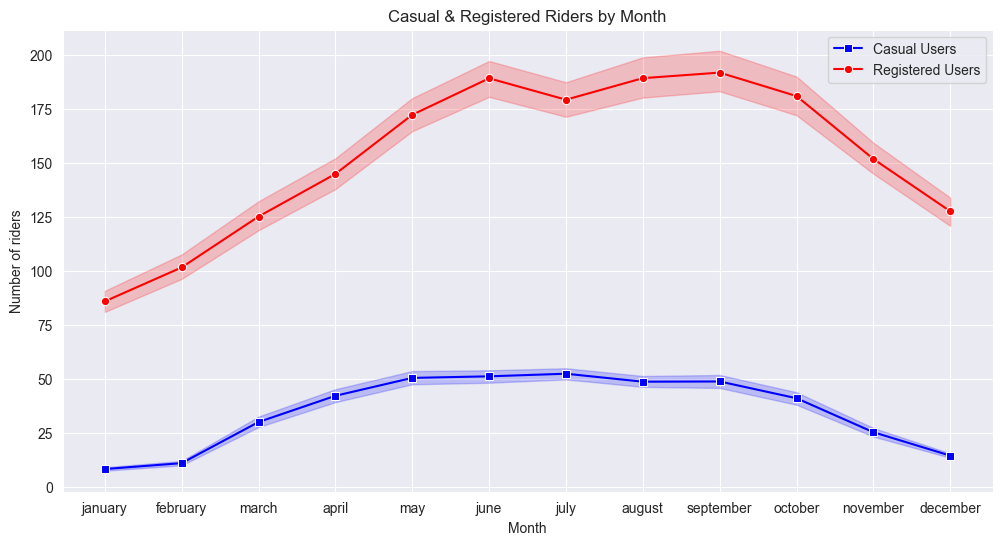

In [230]:
#  Line Chart showing number of registered and casual riders per month

sns.set_style('darkgrid')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hour, x='mnth', y='casual', marker='s', label='Casual Users', color='blue')
sns.lineplot(data=df_hour, x='mnth', y='registered', marker='o', label='Registered Users', color='red')

plt.xlabel('Month')
plt.ylabel('Number of riders')
plt.title('Casual & Registered Riders by Month')
plt.show()

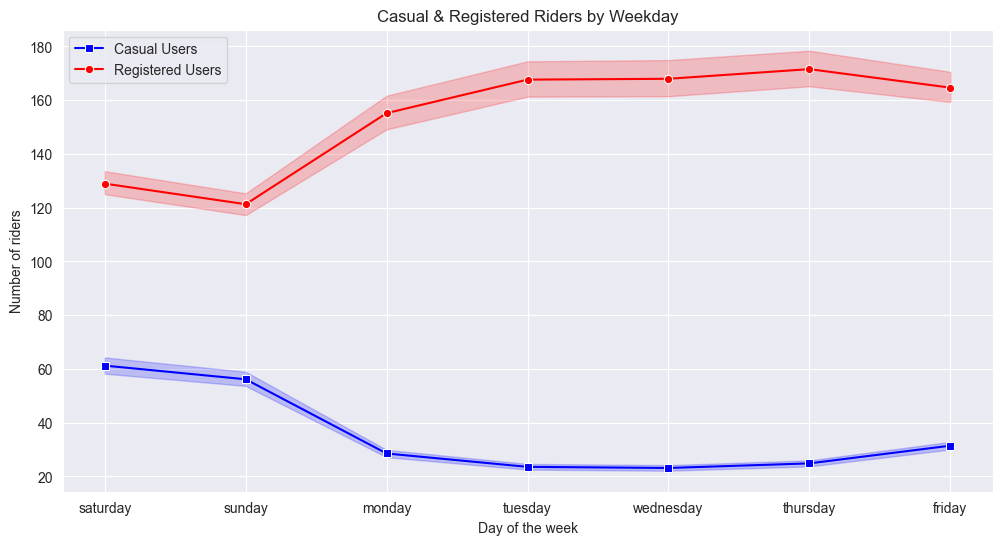

In [232]:
#  Line Chart showing number of registered and casual riders per day of the week

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hour, x='weekday', y='casual', marker='s', label='Casual Users', color='blue')
sns.lineplot(data=df_hour, x='weekday', y='registered', marker='o', label='Registered Users', color='red')

plt.xlabel('Day of the week')
plt.ylabel('Number of riders')
plt.title('Casual & Registered Riders by Weekday')
plt.show()

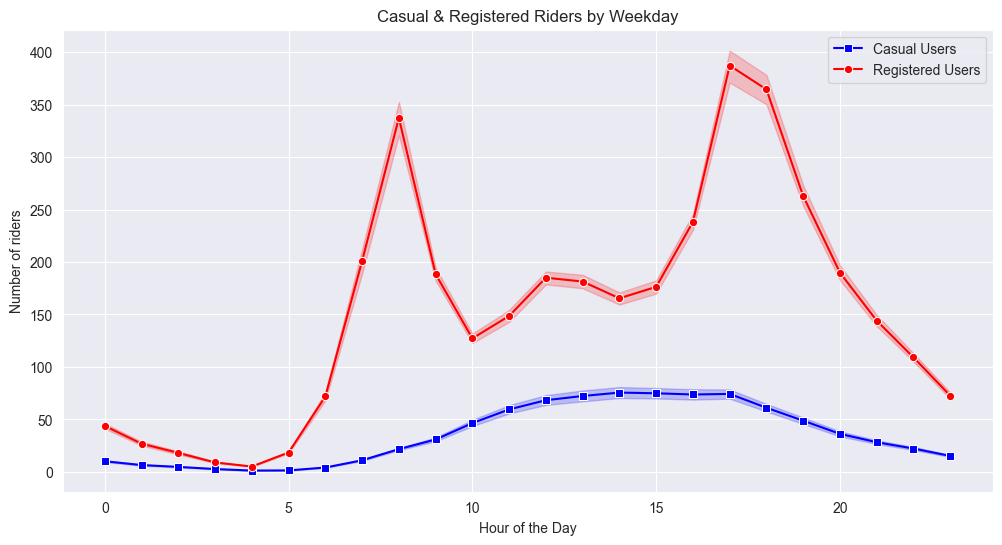

In [233]:
#  Line Chart showing number of registered and casual riders per hour of the day

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hour, x='hr', y='casual', marker='s', label='Casual Users', color='blue')
sns.lineplot(data=df_hour, x='hr', y='registered', marker='o', label='Registered Users', color='red')

plt.xlabel('Hour of the Day')
plt.ylabel('Number of riders')
plt.title('Casual & Registered Riders by Weekday')
plt.show()

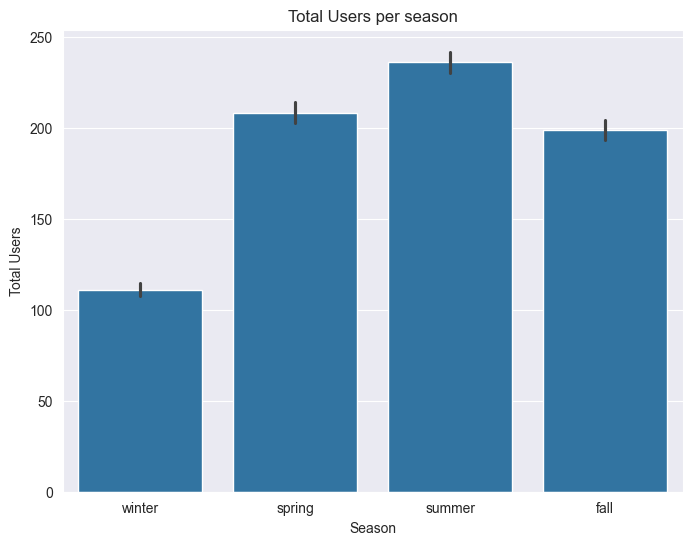

In [235]:
# Bar chart of total users per season

plt.figure(figsize=(8, 6))
sns.barplot(data=df_hour, x='season', y='cnt')

plt.title('Total Users per season')
plt.xlabel('Season')
plt.ylabel('Total Users')
plt.show()

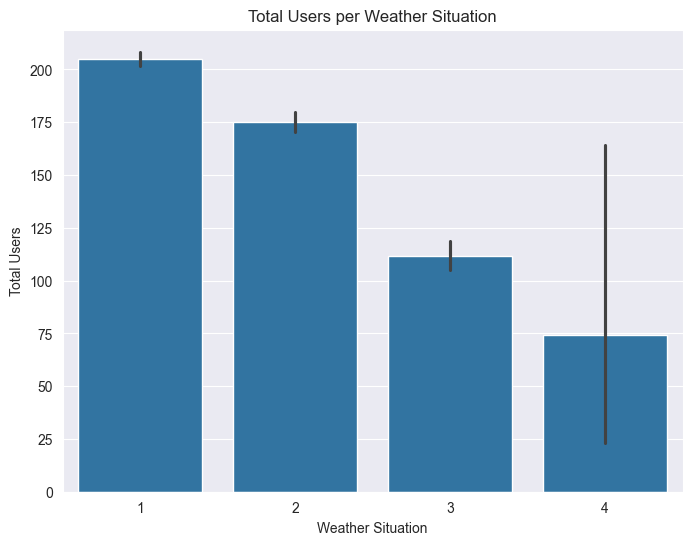

In [236]:
# Bar chart of total users by weather situation

plt.figure(figsize=(8, 6))
sns.barplot(data=df_hour, x='weathersit', y='cnt')

plt.title('Total Users per Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Total Users')
plt.show()

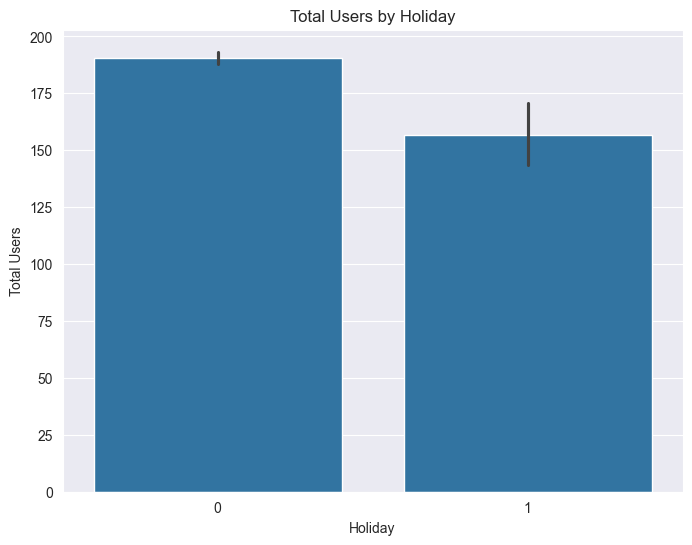

In [241]:
# Bar chart of total users by holiday 

plt.figure(figsize=(8, 6))
sns.barplot(data=df_hour, x='holiday', y='cnt')

plt.title('Total Users by Holiday')
plt.xlabel('Holiday')
plt.ylabel('Total Users')
plt.show()

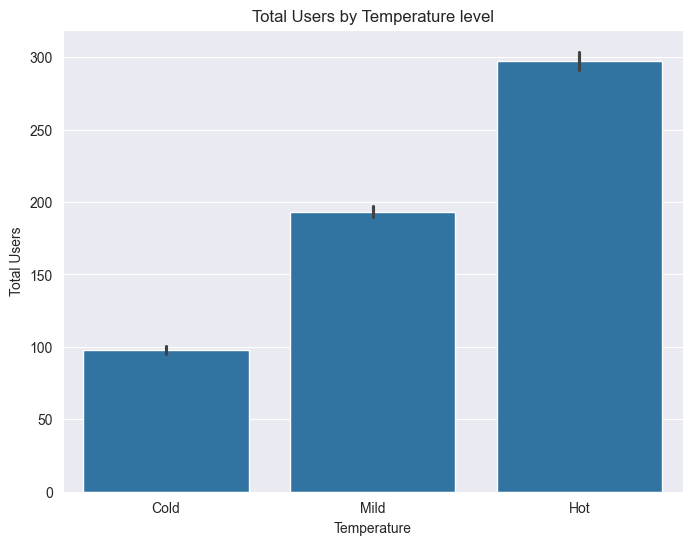

In [242]:
# Bar chart of total users by temperature level 

plt.figure(figsize=(8, 6))
sns.barplot(data=df_hour, x='temp2_binned', y='cnt')

plt.title('Total Users by Temperature level')
plt.xlabel('Temperature')
plt.ylabel('Total Users')
plt.show()

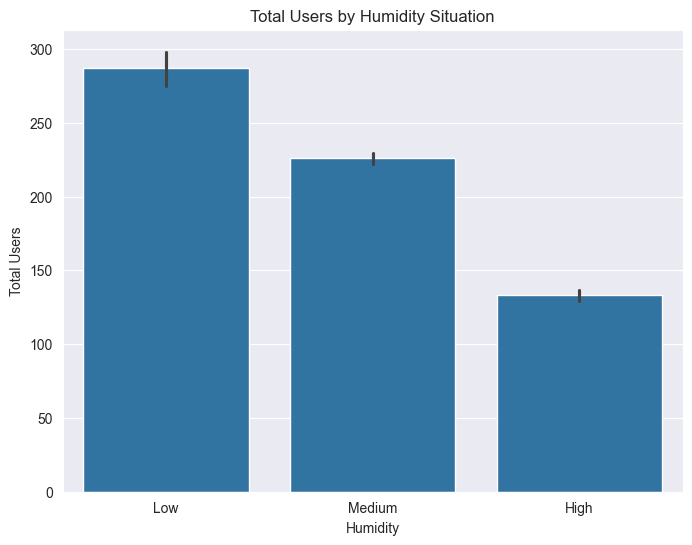

In [243]:
# Bar chart of total users by humidity situation 

plt.figure(figsize=(8, 6))
sns.barplot(data=df_hour, x='hum2_binned', y='cnt')

plt.title('Total Users by Humidity Situation')
plt.xlabel('Humidity')
plt.ylabel('Total Users')
plt.show()

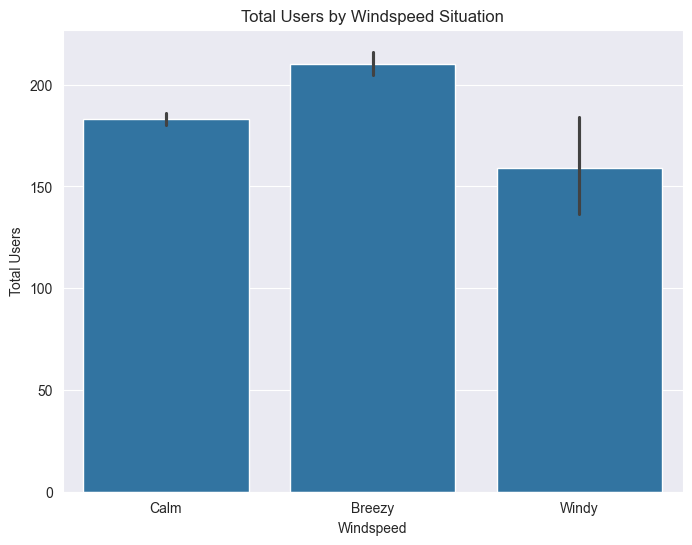

In [244]:
# Bar chart of total users by wind speed situation 

plt.figure(figsize=(8, 6))
sns.barplot(data=df_hour, x='windspeed2_binned', y='cnt')

plt.title('Total Users by Windspeed Situation')
plt.xlabel('Windspeed')
plt.ylabel('Total Users')
plt.show()

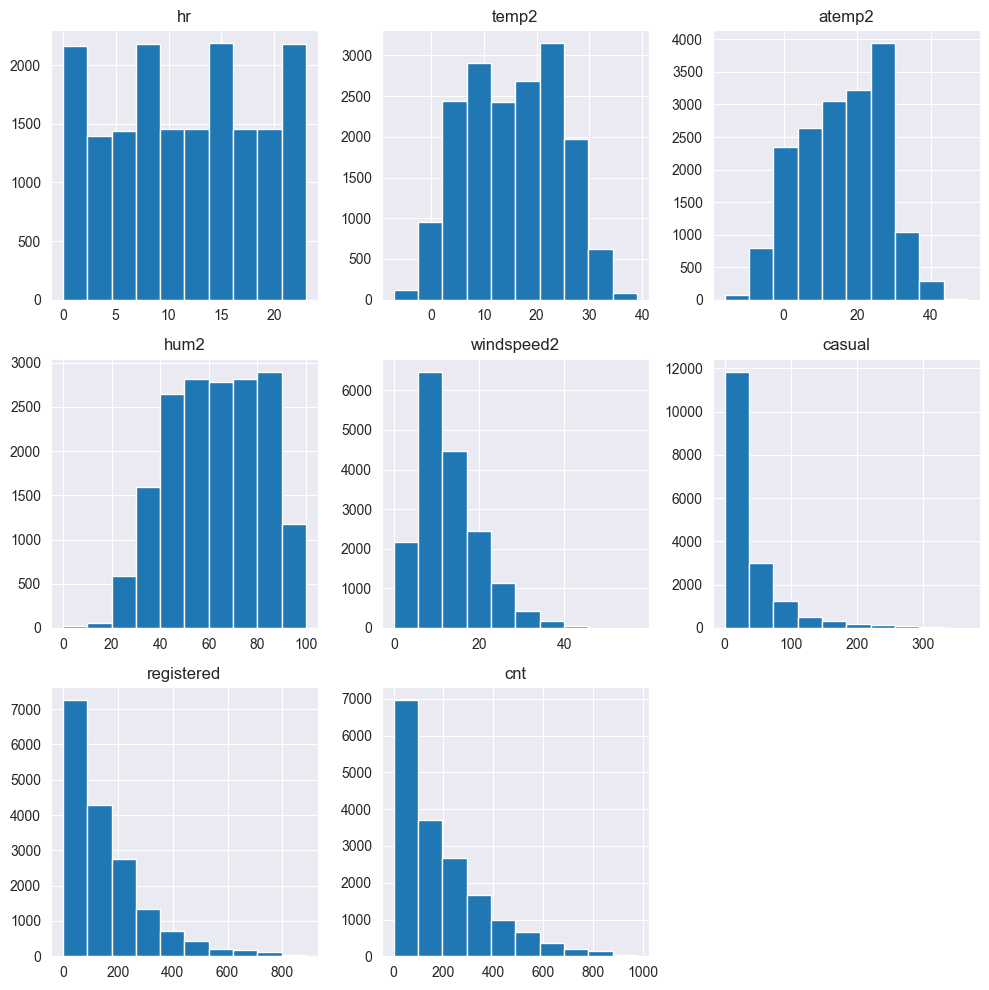

In [245]:
# Display distribution of select variables with histogram

selected_columns = ['hr', 'temp2', 'atemp2', 'hum2', 'windspeed2', 'casual', 'registered', 'cnt']
df_hour[selected_columns].hist(xlabelsize=10, ylabelsize=10, figsize=(10,10), bins=10)
plt.tight_layout()
plt.show()